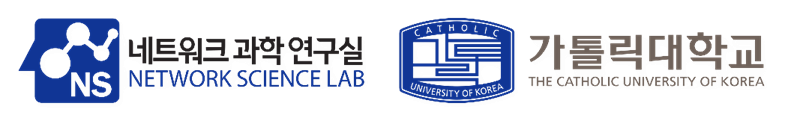

<h1><center><b>💻 Assignment 5:</b> </br>🌟 Graph Communities & Partitioning</center></h1>

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W5/Assignment_5.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> 🌸 **Submission Reminder**
>
> Please make sure to **submit your `.ipynb` (Jupyter Notebook) file** for grading.  
> Other formats such as **PDF, screenshots, or `.py` files** cannot be accepted.  
>
> Thank you and happy coding! 💻✨

## 1. Analyzing a Small Friendship Network 

Imagine a small social network of 12 students (nodes 0 to 11) where edges represent close friendships. The friendship connections are given by the following edge list: 
(0, 1), (0, 2), (0, 7), (1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (4, 6), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11).

**Question 1.** Calculate the modularity of this network given the following groupings of students:

`[{1, 2, 4}, {5, 6, 7}, {0, 7}]`

**Question 2.** Find the maximum clique (the largest group of students where everyone is friends with everyone else) in the graph.

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
import networkx.algorithms.community as nx_comm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
# Section 1: Small Friendship Network
edges = [(0, 1), (0, 2), (0, 7), (1, 2), (1, 3), (2, 3), (3, 4), (4, 5), (4, 6), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)]
G = nx.Graph()
G.add_edges_from(edges)
print('Graph created with', G.number_of_nodes(), 'nodes and', G.number_of_edges(), 'edges')

# Modularity function
def modularity(G, partition):
    W = sum(G.edges[v, w].get('weight', 1) for v, w in G.edges)
    summation = 0
    for cluster_nodes in partition:
        s_c = sum(G.degree(n, weight='weight') for n in cluster_nodes)
        C = G.subgraph(cluster_nodes)
        W_c = sum(C.edges[v, w].get('weight', 1) for v, w in C.edges)
        summation += W_c - s_c ** 2 / (4 * W)
    return summation / W

# Question 1: modularity of given (imperfect) groupings
partition = [{1, 2, 4}, {5, 6, 7}, {0, 7}]
mod_val = modularity(G, partition)
print('Q1. Modularity of given groupings [{1,2,4}, {5,6,7}, {0,7}]:', round(mod_val, 6))
print('   Note: This grouping has overlaps and does not cover all nodes (low modularity expected).')

# Question 2: maximum clique
cliques = list(nx.find_cliques(G))
max_clique = max(cliques, key=len)
print('Q2. Maximum clique size:', len(max_clique), 'nodes')
print('   Members of a max clique:', sorted(max_clique))
print('   (There are multiple cliques of this size: triangles {0,1,2}, {1,2,3}, {4,5,6})')


Graph created with 12 nodes and 15 edges
Q1. Modularity of given groupings [{1,2,4}, {5,6,7}, {0,7}]: 0.065556
   Note: This grouping has overlaps and does not cover all nodes (low modularity expected).
Q2. Maximum clique size: 3 nodes
   Members of a max clique: [0, 1, 2]
   (There are multiple cliques of this size: triangles {0,1,2}, {1,2,3}, {4,5,6})


### 2. NCAA College Football Network

The file "football.gml" contains the network of American football games between Division IA colleges during the Fall 2000 regular season. Node groups represent football conferences (teams that play each other more often). You can extract this data using Python's `zipfile` module and `nx.parse_gml` to read the network into networkX.

**Question 1.** Compute communities representing the natural conferences using the Louvain algorithm.

**Question 2.** Visualize the global network, coloring each node based on the community assigned by the Louvain method. Make the graph visually appealing (e.g., lower the opacity of edges to let nodes stand out, and use `k` or other parameters in the layout model to spread the nodes out clearly).

**Question 3.** Select two communities and isolate them into subgraphs, then visualize them side-by-side or individually to show the tight-knit games within each community.

In [10]:
# Helper functions 
def create_community_node_colors(graph, communities):
    number_of_colors = len(communities)
    colors = ['#EF9A9A', '#BA68C8', '#64B5F6', '#81C784', '#FFF176', '#BDBDBD', '#FF8A65', '#4DB6AC', '#7986CB'][:number_of_colors]
    node_to_community = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_community[node] = i
    node_colors = [colors[node_to_community[node]] for node in graph.nodes()]
    return node_colors

def get_louvain_communities(graph, random_state=42):
    louvain_partition_dict = community_louvain.best_partition(graph, random_state=random_state)
    unique_partition_labels = list(set(louvain_partition_dict.values()))
    communities = [[] for i in range(len(unique_partition_labels))]
    for node in louvain_partition_dict.keys():
        communities[louvain_partition_dict[node]].append(node)
    return [set(c) for c in communities]


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
import networkx.algorithms.community as nx_comm
import zipfile
import io

# Helper functions (kept local so this cell is self-contained)
def create_community_node_colors(graph, communities):
    number_of_colors = len(communities)
    colors = ['#EF9A9A', '#BA68C8', '#64B5F6', '#81C784', '#FFF176', '#BDBDBD', '#FF8A65', '#4DB6AC', '#7986CB'][:number_of_colors]
    node_to_community = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_community[node] = i
    node_colors = [colors[node_to_community[node]] for node in graph.nodes()]
    return node_colors


def get_louvain_communities(graph, random_state=42):
    louvain_partition_dict = community_louvain.best_partition(graph, random_state=random_state)
    unique_partition_labels = list(set(louvain_partition_dict.values()))
    communities = [[] for i in range(len(unique_partition_labels))]
    for node in louvain_partition_dict.keys():
        communities[louvain_partition_dict[node]].append(node)
    return [set(c) for c in communities]

Gf = None
# Try zip first (e.g. football.zip containing football.gml)
for zpath in ["data/football.zip", "football.zip"]:
    try:
        with zipfile.ZipFile(zpath) as zf:
            gml_bytes = zf.read("football.gml")
            gml_text = gml_bytes.decode("utf-8")
            # parse_gml accepts lines or str; split to lines for safety
            Gf = nx.parse_gml(gml_text.splitlines())
            print("Loaded via zipfile + nx.parse_gml from", zpath)
            break
    except Exception:
        pass

if Gf is None:
    for gpath in ["data/football.gml", "football.gml"]:
        try:
            Gf = nx.read_gml(gpath)
            print("Loaded via nx.read_gml:", gpath)
            break
        except FileNotFoundError:
            continue

if Gf is None:
    raise FileNotFoundError("Could not find football.gml or football.zip")

print("Football network:", Gf.number_of_nodes(), "nodes,", Gf.number_of_edges(), "edges")
print("Conferences (value):", sorted(set(nx.get_node_attributes(Gf, "value").values())))

# Q1. Compute Louvain communities
louvain_comms = get_louvain_communities(Gf, random_state=42)
mod_f = nx_comm.modularity(Gf, louvain_comms)
print("Q1. Louvain found", len(louvain_comms), "communities with modularity", round(mod_f, 6))
sizes = sorted([len(c) for c in louvain_comms], reverse=True)
print("   Community sizes:", sizes)


Loaded via nx.read_gml: data/football.gml
Football network: 115 nodes, 613 edges
Conferences (value): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Q1. Louvain found 9 communities with modularity 0.604184
   Community sizes: [24, 17, 14, 12, 11, 10, 9, 9, 9]


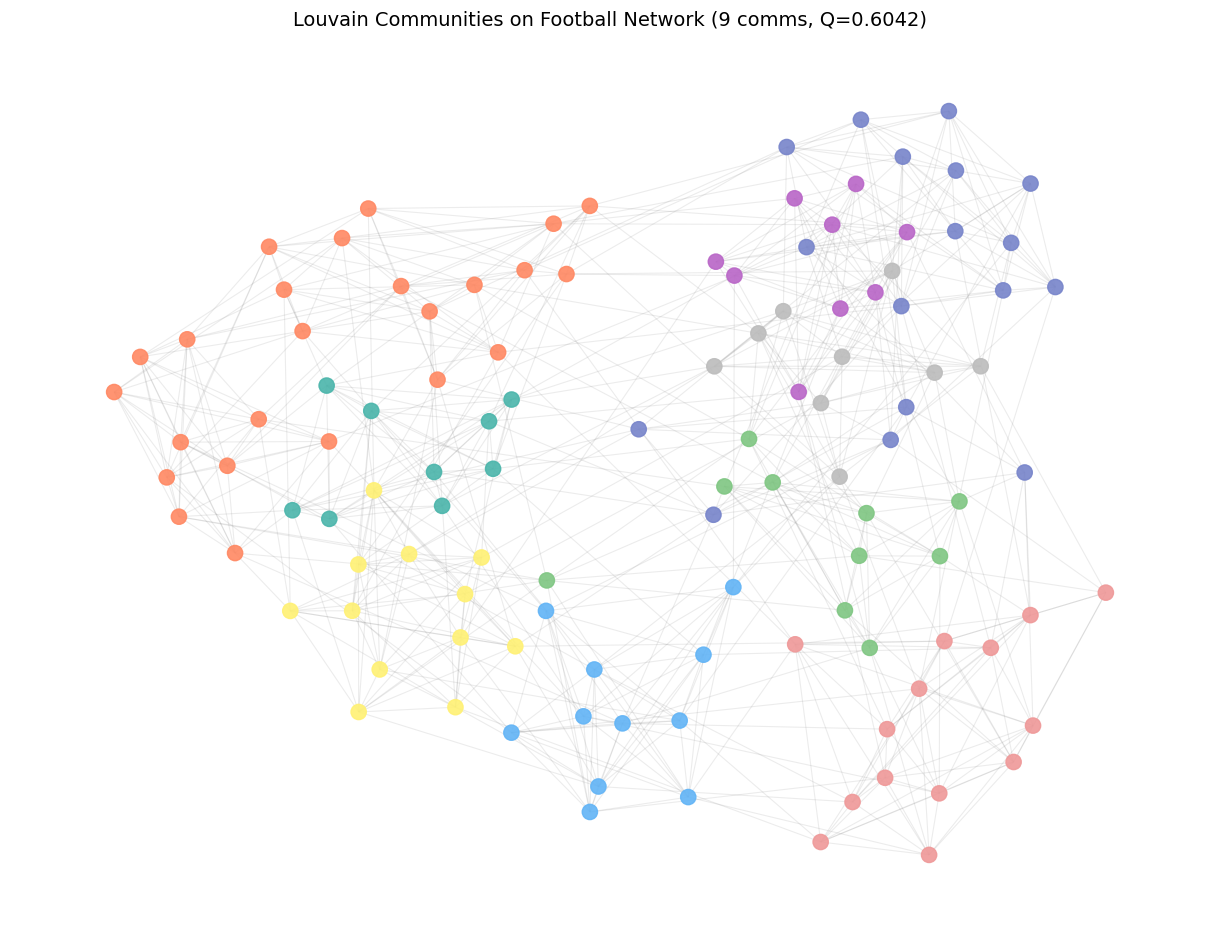

Q2. Visualization rendered above (edges faded, nodes spread via spring k=0.25)


In [12]:
# Q2. Visualize global network colored by Louvain communities
# Make visually appealing: low edge opacity, spread with k param
node_colors = create_community_node_colors(Gf, louvain_comms)
pos = nx.spring_layout(Gf, k=0.25, iterations=80, seed=42)  # k spreads nodes

plt.figure(figsize=(12, 9))
nx.draw(Gf, pos=pos,
        node_color=node_colors,
        node_size=120,
        with_labels=False,  # labels clutter; use if small
        edge_color='gray',
        alpha=0.15,           # low opacity edges
        width=0.8)
nx.draw_networkx_nodes(Gf, pos, node_color=node_colors, node_size=120, alpha=0.9)
plt.title(f'Louvain Communities on Football Network ({len(louvain_comms)} comms, Q={mod_f:.4f})', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
print('Q2. Visualization rendered above (edges faded, nodes spread via spring k=0.25)')


Selected community A size: 24 B size: 17


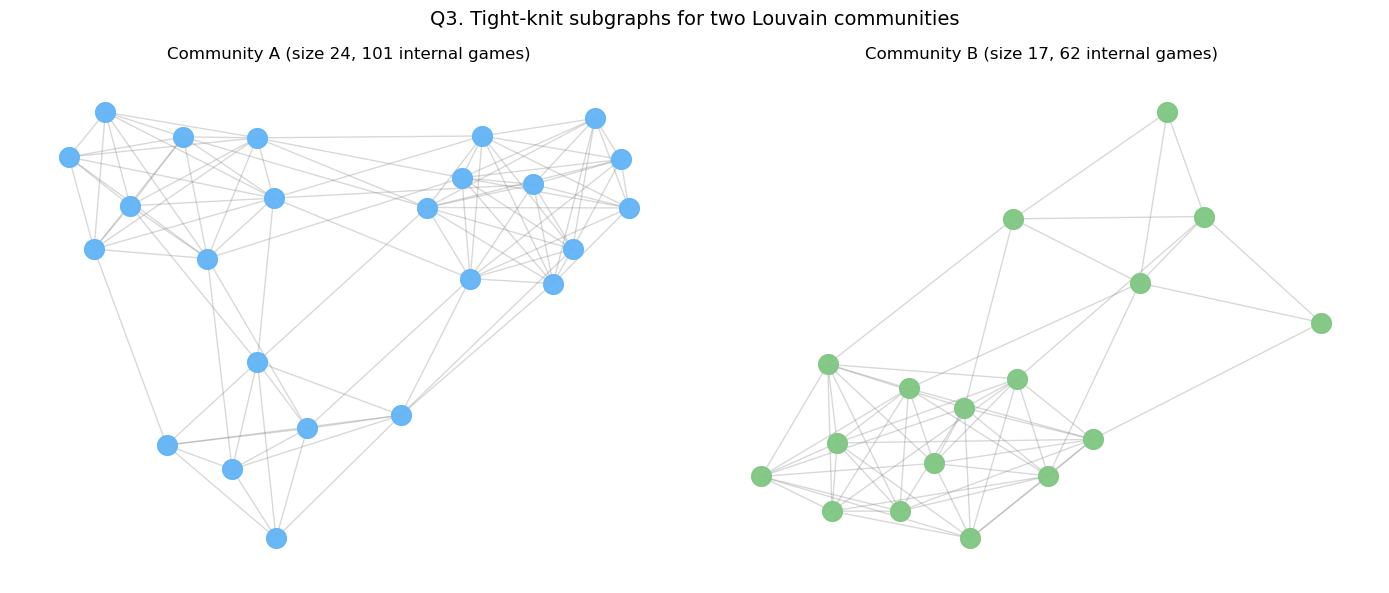

In [16]:
# Q3. Isolate two communities and visualize subgraphs side-by-side
# Pick the two largest for clear tight-knit examples
sorted_comms = sorted(louvain_comms, key=len, reverse=True)
cA, cB = sorted_comms[0], sorted_comms[1]
print('Selected community A size:', len(cA), 'B size:', len(cB))

GA = Gf.subgraph(cA).copy()
GB = Gf.subgraph(cB).copy()

posA = nx.spring_layout(GA, k=0.4, seed=1)
posB = nx.spring_layout(GB, k=0.4, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])
nx.draw(GA, pos=posA, node_color='#64B5F6', node_size=200, with_labels=False,
        edge_color='gray', alpha=0.3, width=1.0)
nx.draw_networkx_nodes(GA, posA, node_color='#64B5F6', node_size=200, alpha=0.95)
axes[0].set_title(f'Community A (size {len(cA)}, {GA.number_of_edges()} internal games)', fontsize=12)
axes[0].axis('off')

plt.sca(axes[1])
nx.draw(GB, pos=posB, node_color='#81C784', node_size=200, with_labels=False,
        edge_color='gray', alpha=0.3, width=1.0)
nx.draw_networkx_nodes(GB, posB, node_color='#81C784', node_size=200, alpha=0.95)
axes[1].set_title(f'Community B (size {len(cB)}, {GB.number_of_edges()} internal games)', fontsize=12)
axes[1].axis('off')

plt.suptitle('Q3. Tight-knit subgraphs for two Louvain communities', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Zachary's Karate Club (A Faction Split)

The famous Zachary's Karate Club edge list (`data/Karate_edgelist.txt`) represents social ties in a university karate club. Due to an internal conflict between the instructor (often represented by a high-degree node, say Node 1 or 34) and the club president, the club eventually split into two factions. 

**Question 1.** Compute the local clustering coefficient for each member in the network. Provide a well-formatted graph overview using Spring layout.

**Question 2.** Find all "tight-knit" members—nodes whose local clustering coefficient is exactly 1 (meaning their friends are also all friends with each other, forming a complete local graph). Furthermore, visualize the overall network and highlight these tightly embedded members in a contrasting color (e.g., gold/yellow stars).

Karate club graph: 34 nodes, 77 edges
Local clustering coefficients for all members (0-33):
  Node  0: 0.1500
  Node  1: 0.3333
  Node  2: 0.2444
  Node  3: 0.6667
  Node  4: 0.6667
  Node  5: 0.5000
  Node  6: 0.5000
  Node  7: 1.0000
  Node  8: 0.5000
  Node  9: 0.0000
  Node 10: 0.6667
  Node 11: 0.0000
  Node 12: 1.0000
  Node 13: 0.6000
  Node 14: 1.0000
  Node 15: 1.0000
  Node 16: 1.0000
  Node 17: 1.0000
  Node 18: 1.0000
  Node 19: 0.3333
  Node 20: 1.0000
  Node 21: 1.0000
  Node 22: 1.0000
  Node 23: 0.4000
  Node 24: 0.3333
  Node 25: 0.3333
  Node 26: 1.0000
  Node 27: 0.1667
  Node 28: 0.3333
  Node 29: 0.6667
  Node 30: 0.3333
  Node 31: 0.2000
  Node 32: 0.1818
  Node 33: 0.1029


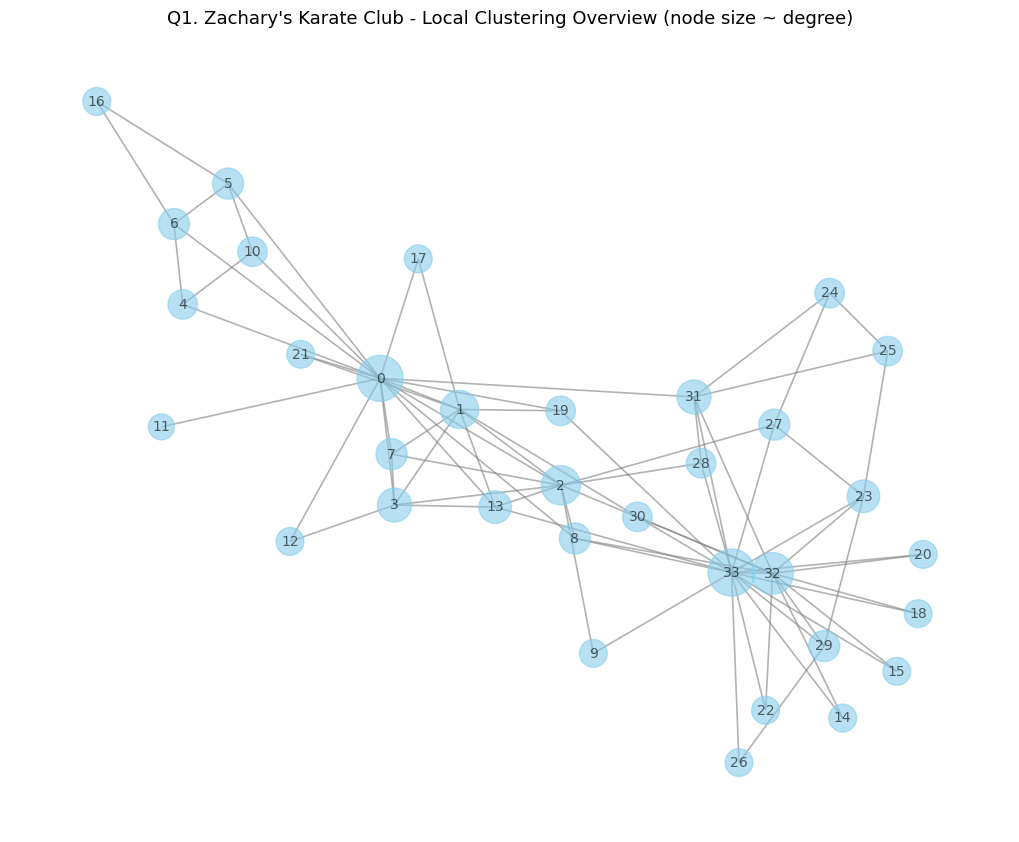

In [ ]:
# Load the edgelist
try:
    Gk = nx.read_edgelist('data/Karate_Edgelist.txt', nodetype=int)
except FileNotFoundError:
    Gk = nx.read_edgelist('Karate_Edgelist.txt', nodetype=int)
print('Karate club graph:', Gk.number_of_nodes(), 'nodes,', Gk.number_of_edges(), 'edges')

# Q1. Local clustering coefficient for each member + overview viz
clustering = nx.clustering(Gk)
print('Local clustering coefficients for all members (0-33):')
for n in sorted(Gk.nodes()):
    print(f'  Node {n:2d}: {clustering[n]:.4f}')

# Well-formatted spring layout overview
posk = nx.spring_layout(Gk, k=0.3, iterations=50, seed=42)
degrees = dict(Gk.degree())
node_sizes = [300 + 50 * degrees[n] for n in Gk.nodes()] 

plt.figure(figsize=(10, 8))
nx.draw(Gk, pos=posk,
        node_color='skyblue',
        node_size=node_sizes,
        with_labels=True,
        font_size=10,
        font_color='black',
        edge_color='gray',
        alpha=0.6,
        width=1.2)
plt.title("Q1. Zachary's Karate Club - Local Clustering Overview (node size ~ degree)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()


Q2. Tight-knit members (clustering coeff exactly 1.0): [7, 12, 14, 15, 16, 17, 18, 20, 21, 22, 26]
   Count: 11 - their neighbors form cliques (all friends are mutual).


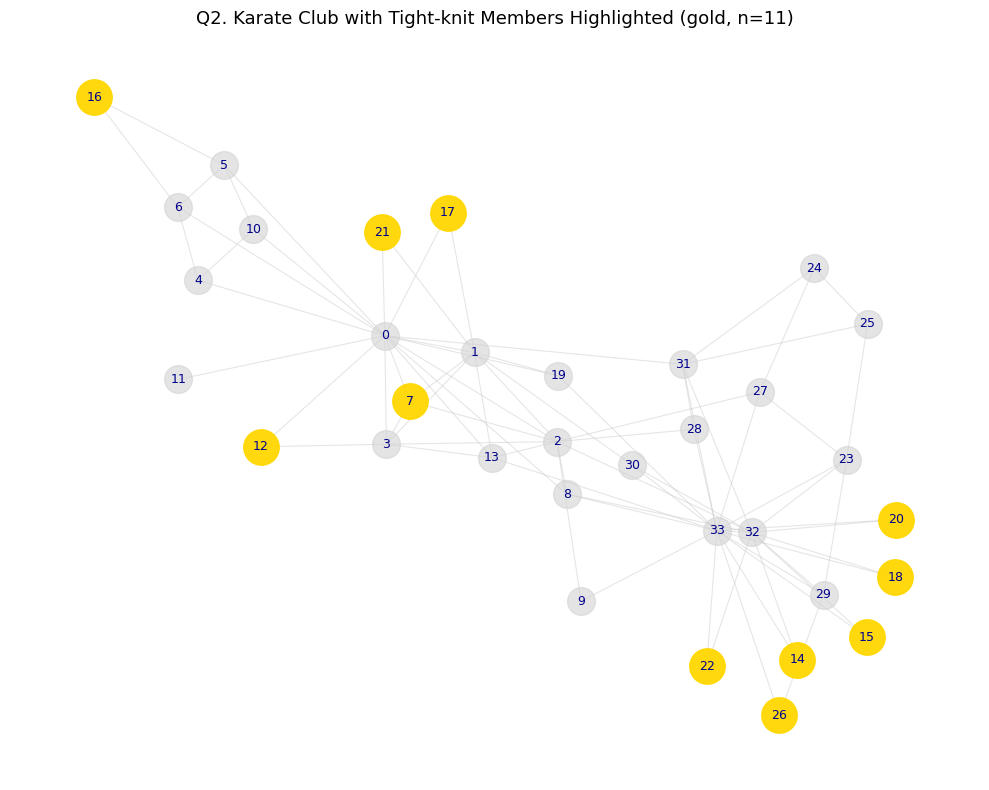

In [17]:
# Q2. Find tight-knit members (local clustering coeff == 1.0) and highlight
tight_knit = [n for n, c in clustering.items() if c == 1.0]
print('Q2. Tight-knit members (clustering coeff exactly 1.0):', sorted(tight_knit))
print('   Count:', len(tight_knit), '- their neighbors form cliques (all friends are mutual).')

# Visualize: all nodes + highlight tight-knit in gold/yellow with star-like emphasis
posk2 = nx.spring_layout(Gk, k=0.3, iterations=60, seed=42)

plt.figure(figsize=(10, 8))

# non-tight nodes
non_tight = [n for n in Gk.nodes() if n not in tight_knit]
nx.draw_networkx_nodes(Gk, posk2, nodelist=non_tight,
                       node_color='lightgray', node_size=400, alpha=0.6)

# tight-knit highlighted
nx.draw_networkx_nodes(Gk, posk2, nodelist=tight_knit,
                       node_color='gold', node_size=650, alpha=0.95, node_shape='o')

# draw edges lighter
nx.draw_networkx_edges(Gk, posk2, edge_color='silver', alpha=0.4, width=0.8)

# labels
nx.draw_networkx_labels(Gk, posk2, font_size=9, font_color='darkblue')

plt.title(f"Q2. Karate Club with Tight-knit Members Highlighted (gold, n={len(tight_knit)})", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()